In [ ]:
!pip install pandas numpy scikit-learn m2cgen

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.2/92.2 kB 1.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Aggregrated_Data.csv to Aggregrated_Data.csv


In [ ]:
dataset = pd.read_csv("/content/Aggregrated_Data.csv")
dataset.head()

,timestamp,satellite_prn,satellite_elevation_deg,satellite_azimuth_deg,temperature_C,humidity_%,rain_intensity_mm_hr,rain_sensor_value,snr_measured_dbhz,label
0,2024-01-01 00:00,8.23,44.94,313.18,34.99,58.64,0.00,0.00,51,0
1,2024-01-01 00:00,2.94,22.20,200.38,33.96,55.17,0.57,0.00,47,0
2,2024-01-01 00:00,11.30,26.44,162.51,32.92,50.66,0.00,0.00,42,0
3,2024-01-01 00:00,26.70,77.68,58.32,31.32,40.02,1.36,0.00,44,0
4,2024-01-01 00:00,21.89,82.50,54.38,28.65,89.37,2.79,49.88,39,1


In [ ]:
dataset = dataset[
    (dataset["satellite_elevation_deg"] >= 10) &
    (dataset["satellite_elevation_deg"] <= 70) &
    (dataset["satellite_azimuth_deg"] >= 0) &
    (dataset["satellite_azimuth_deg"] <= 360) &
    (dataset["satellite_prn"] >= 1) &
    (dataset["satellite_prn"] <= 32)
]

In [ ]:
print("Dataset size after filtering:", dataset.shape)

Dataset size after filtering: (20328, 10)


In [ ]:
print(dataset.isnull().sum())

timestamp                  0
satellite_prn              0
satellite_elevation_deg    0
satellite_azimuth_deg      0
temperature_C              0
humidity_%                 0
rain_intensity_mm_hr       0
rain_sensor_value          0
snr_measured_dbhz          0
label                      0
dtype: int64


In [ ]:
(dataset == 0).sum()

,0
timestamp,0
satellite_prn,0
satellite_elevation_deg,0
satellite_azimuth_deg,659
temperature_C,618
humidity_%,629
rain_intensity_mm_hr,4119
rain_sensor_value,4359
snr_measured_dbhz,608
label,8146


In [ ]:
columns_to_fix = [
    "satellite_prn",
    "satellite_elevation_deg",
    "satellite_azimuth_deg",
    "temperature_C",
    "humidity_%",
    "rain_sensor_value",
    "snr_measured_dbhz"
]

for col in columns_to_fix:

    mean_value = dataset.loc[dataset[col] != 0, col].mean()

    dataset[col] = dataset[col].replace(0, mean_value)

In [ ]:
features = dataset[[
    "satellite_prn",
    "satellite_elevation_deg",
    "satellite_azimuth_deg",
    "temperature_C",
    "humidity_%",
    "rain_sensor_value",
    "snr_measured_dbhz"
]]

labels = dataset["label"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestClassifier(

    n_estimators = 5,
    max_depth = 4,
    min_samples_leaf = 5,
    random_state = 42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=4, min_samples_leaf=5, n_estimators=5,
                       random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9756517461878996


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1580   47    0]
 [  25 1185    2]
 [   0   25 1202]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1627
           1       0.94      0.98      0.96      1212
           2       1.00      0.98      0.99      1227

    accuracy                           0.98      4066
   macro avg       0.98      0.98      0.98      4066
weighted avg       0.98      0.98      0.98      4066



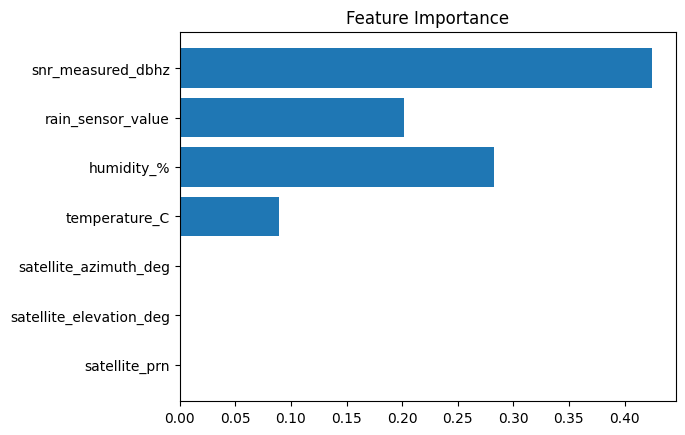

In [ ]:
importance = model.feature_importances_
feature_names = features.columns

plt.barh(feature_names, importance)
plt.title("Feature Importance")
plt.show()

In [38]:
import m2cgen as m2c

In [39]:
c_code = m2c.export_to_c(model)
print(c_code)

#include <string.h>
void add_vectors(double *v1, double *v2, int size, double *result) {
    for(int i = 0; i < size; ++i)
        result[i] = v1[i] + v2[i];
}
void mul_vector_number(double *v1, double num, int size, double *result) {
    for(int i = 0; i < size; ++i)
        result[i] = v1[i] * num;
}
void score(double * input, double * output) {
    double var0[3];
    double var1[3];
    double var2[3];
    double var3[3];
    double var4[3];
    double var5[3];
    if (input[4] <= 65.36000061035156) {
        if (input[4] <= 64.36999893188477) {
            if (input[5] <= 143.49942016601562) {
                if (input[6] <= 40.5) {
                    memcpy(var5, (double[]){0.9633507853403142, 0.03664921465968586, 0.0}, 3 * sizeof(double));
                } else {
                    memcpy(var5, (double[]){1.0, 0.0, 0.0}, 3 * sizeof(double));
                }
            } else {
                memcpy(var5, (double[]){1.0, 0.0, 0.0}, 3 * sizeof(double));
            }
      

In [40]:
with open("Random_Forest_model.c", "w") as f:
    f.write(c_code)

In [41]:
files.download("Random_Forest_model.c")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>